# Proyecto - Computación Avanzada

## Estudio de caso para 4 poblaciones (2 depredadores y 2 presas)

In [1]:
from pesca_env import Pesca4D
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

In [2]:
"""
Orden de los datos
[Presa1, Presa2, Depredador1, Depredador2]
"""

#Factor de crecimiento de cada poblacion
r = np.array([0.9, 0.7, 0.3, 0.2])

#Factor de ruido agregado al sistema
sigma = 0.05

#Poblacion inicial de cada especie
init_B = np.array([0.4, 0.7, 0.1, 0.2])

#Factor terminated
T = 200

#Factor de mortalidad de cada especie
mort = [0.1, 0.2, 0.3, 0.02]

#Factor de arrastre para presas y cazadores
arrastre = [0.1, 0.2]

#Factor que limita el valor maximo de la poblacion depredadora
C = 1

#Diccionario con los parametros del env
params = { "r_crecimiento": r,
           "sigma": sigma,
           "init_B": init_B,
           "T": T,
           "mortalidad": mort,
           "C": C,
           "epsilon": 1e-5,
           "arrastre": arrastre
}

#Inicializa el ambiente
env = Pesca4D(params)

In [3]:
#Inicializa el modelo
agent = PPO("MlpPolicy", env, verbose=1, device="cpu")

#Entrena el modelo
agent.learn(total_timesteps=25000)

#Guarda el modelo
agent.save("ppo_pesca_4D")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 55.2     |
| time/              |          |
|    fps             | 1197     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | 56.1         |
| time/                   |              |
|    fps                  | 838          |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0039372183 |
|    clip_fraction        | 0.0373       |
|    clip_range           | 0.2          |
|    en

In [4]:
#Carga el modelo (para evitar correr el entrenamiento todas las veces)
agent = PPO.load("ppo_pesca_4D", device="cpu")

In [5]:
#Cantidad de steps
N = 200

#Reinicia el sistema y obtiene la observación inicial
obs, _ = env.reset()

#Listas para guardar la población y el harvest
presa1 = np.zeros(N)
depredador1 = np.zeros(N)
presa2 = np.zeros(N)
depredador2 = np.zeros(N)
harvest = np.zeros(N)

for i in range(N):
    #El agente define una accion segun la observación
    action, _ = agent.predict(obs, deterministic=True)
    action = np.array([-1])

    #Calcula un step del environment segun la acción
   #obs, reward, terminated, truncated, _ = env.step(action)
    obs, reward, terminated, truncated, _ = env.step(action)

    #Registra la población de cada paso
    presa1[i] = env.unnormalize(obs[0])
    presa2[i] = env.unnormalize(obs[1])
    depredador1[i] = env.unnormalize(obs[2])
    depredador2[i] = env.unnormalize(obs[3])

    #Registra los rewards de cada paso
    harvest[i] = reward

## Resultados: Evolución temporal de la población y del harvest

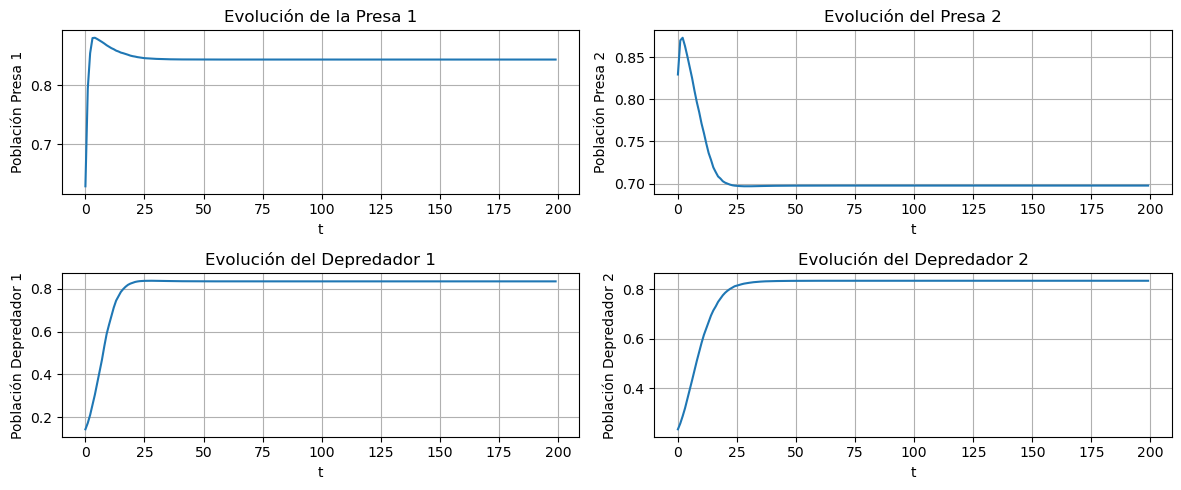

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(12, 5))

# Gráfica de Población1
axs[0,0].plot(presa1)
axs[0,0].set_xlabel("t")
axs[0,0].set_ylabel("Población Presa 1")
axs[0,0].set_title("Evolución de la Presa 1")
axs[0,0].grid(True)

# Gráfica de Población2
axs[0, 1].plot(presa2)
axs[0, 1].set_xlabel("t")
axs[0, 1].set_ylabel("Población Presa 2")
axs[0, 1].set_title("Evolución del Presa 2")
axs[0, 1].grid(True)

# Gráfica de Depredador1
axs[1, 0].plot(depredador1)
axs[1, 0].set_xlabel("t")
axs[1, 0].set_ylabel("Población Depredador 1")
axs[1, 0].set_title("Evolución del Depredador 1")
axs[1, 0].grid(True)

# Gráfica de Depredador2
axs[1, 1].plot(depredador2)
axs[1, 1].set_xlabel("t")
axs[1, 1].set_ylabel("Población Depredador 2")
axs[1, 1].set_title("Evolución del Depredador 2")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

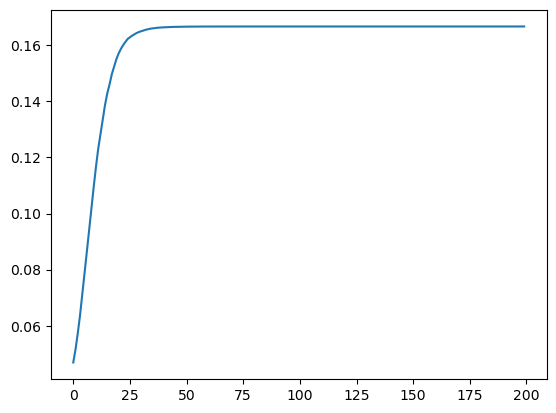

In [9]:
plt.plot(harvest)
plt.show()

## Resultados: Población (Biomasa) en función del harvest (mortalidad por pesca)

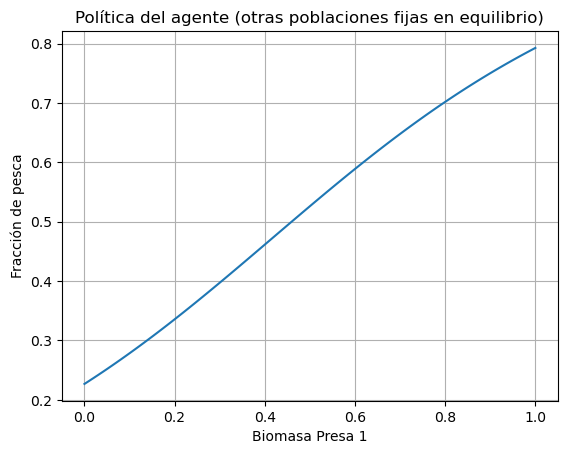

In [10]:
M = 100
biomass = np.linspace(0, 1, M)
actions = np.zeros(M)

# Valores fijos de referencia para las otras poblaciones
presa2_ref    = 0.73  # Ajusta al equilibrio que observaste
depred1_ref   = 0.80
depred2_ref   = 0.80

for i in range(M):
    obs = np.array([
        -1 + 2 * biomass[i],       # Presa1 varía
        -1 + 2 * presa2_ref,       # Presa2 fija
        -1 + 2 * depred1_ref,      # Depredador1 fijo
        -1 + 2 * depred2_ref       # Depredador2 fijo
    ], dtype=np.float32)
    
    action, _ = agent.predict(obs, deterministic=True)
    actions[i] = (action[0] + 1) / 2

plt.plot(biomass, actions)
plt.xlabel("Biomasa Presa 1")
plt.ylabel("Fracción de pesca")
plt.title("Política del agente (otras poblaciones fijas en equilibrio)")
plt.grid(True)
plt.show()